<a href="https://colab.research.google.com/github/DannyJh/EjerciciosRI/blob/main/04bm25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
!pip install -q requests
import requests
import re
import time
from urllib3.util.retry import Retry
from requests.adapters import HTTPAdapter

print("Descargando corpus Gutenberg 1000...")
BASE_API = "https://gutendex.com/books"
MAX_BOOKS = 1000

session = requests.Session()
retries = Retry(total=5, backoff_factor=2, status_forcelist=[429, 500, 502, 503, 504])
session.mount("https://", HTTPAdapter(max_retries=retries))

def limpiar_texto(texto):
    # Toma solo los primeros 1000 caracteres para agilizar el procesamiento en RAM
    texto_limpio = re.sub(r'\n{3,}', '\n\n', texto)
    return texto_limpio[:1000]

docs = []
doc_names = []
downloaded = 0
page = 1

while downloaded < MAX_BOOKS:
    try:
        respuesta = session.get(f"{BASE_API}?page={page}", timeout=60)
        respuesta.raise_for_status()
    except Exception as e:
        print(f"Error en página {page}: {e}")
        break

    libros = respuesta.json().get("results", [])
    if not libros: break

    for libro in libros:
        if downloaded >= MAX_BOOKS: break

        titulo = libro["title"]
        txt_url = None

        for key, value in libro["formats"].items():
            if "text/plain" in key and value:
                txt_url = value
                break

        if not txt_url: continue

        try:
            r = session.get(txt_url, timeout=60)
            if r.status_code == 200:
                docs.append(limpiar_texto(r.text))
                doc_names.append(f"Doc_{downloaded}: {titulo[:30]}")
                downloaded += 1
                if downloaded % 100 == 0:
                    print(f"Descargados {downloaded}/{MAX_BOOKS} libros...")
        except:
            continue
    page += 1

print(f"\nSe cargaron {len(docs)} documentos en memoria.")

Descargando corpus Gutenberg 1000...
Descargados 100/1000 libros...
Descargados 200/1000 libros...
Descargados 300/1000 libros...
Descargados 400/1000 libros...
Descargados 500/1000 libros...
Descargados 600/1000 libros...
Descargados 700/1000 libros...
Descargados 800/1000 libros...
Descargados 900/1000 libros...
Descargados 1000/1000 libros...

Se cargaron 1000 documentos en memoria.


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Construye la matriz de términos (TF)
print("Construyendo matriz TF...")
count_vectorizer = CountVectorizer(stop_words='english', max_features=3000)
tf_matrix = count_vectorizer.fit_transform(docs)

# Calcula la frecuencia de documentos (DF)
df = np.array((tf_matrix > 0).sum(axis=0)).flatten()

# 2. Calcula TF-IDF utilizando sklearn
print("Calculando TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
tfidf_matrix = tfidf_vectorizer.fit_transform(docs)

# 3. Visualiza los valores en un DataFrame
terminos = tfidf_vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray()[:50], columns=terminos, index=doc_names[:50]) # Mostramos solo 50 para no saturar la salida

print("Muestra de la matriz TF-IDF (Primeros 50 documentos):")
display(tfidf_df.head(10))

Construyendo matriz TF...
Calculando TF-IDF...
Muestra de la matriz TF-IDF (Primeros 50 documentos):


,00,000,01,02,03,04,05,06,07,08,...,灵历集光,狄公案,第一回,紅樓夢,耳食錄,自序,西江月,西遊記,詩曰,警世通言
"Doc_0: The City of God, Volume I",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Doc_1: Frankenstein; or, the modern p",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Doc_2: Moby Dick; Or, The Whale",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc_3: Pride and Prejudice,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc_4: Crime and Punishment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc_5: Romeo and Juliet,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc_6: Alice's Adventures in Wonderla,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc_7: The origin and development of,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc_8: A Room with a View,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Doc_9: The strange case of Dr. Jekyll,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Dada una consulta, construye el vector de consulta
consulta = "love war king" # Usamos una consulta inspirada en tu tarea anterior
query_vector = tfidf_vectorizer.transform([consulta])

# 2. Calcula la similitud coseno entre la consulta y cada documento
similitudes = cosine_similarity(query_vector, tfidf_matrix).flatten()

# 3. Genera un ranking de los documentos ordenados por relevancia
ranking_tfidf = pd.DataFrame({
    'Documento': doc_names,
    'Score TF-IDF': similitudes
}).sort_values(by='Score TF-IDF', ascending=False)

# 4. Muestra los resultados en una tabla
print(f"Ranking TF-IDF para la consulta: '{consulta}'")
display(ranking_tfidf.head(10))

Ranking TF-IDF para la consulta: 'love war king'


,Documento,Score TF-IDF
206,Doc_206: The Art of War,0.314784
411,Doc_411: Love-at-arms : $b being a narr,0.312830
219,Doc_219: Love and Freindship [sic],0.285661
551,Doc_551: The History of the Peloponnesi,0.274413
68,Doc_68: War and Peace,0.271640
403,Doc_403: Love's Labour's Lost,0.255289
239,Doc_239: The war of the worlds,0.253335
458,Doc_458: On War,0.242088
12,Doc_12: The King in Yellow,0.231418
343,Doc_343: India's Love Lyrics,0.230506


## Parte 3: Ranking con BM25

### Actividad

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [4]:
import math

# 1. Tokenización
tokenizer = count_vectorizer.build_analyzer()
tokenized_docs = [tokenizer(doc) for doc in docs]
tokenized_query = tokenizer(consulta)

# 2. Calcular longitudes de documentos y promedio de longitud
doc_lengths = [len(doc) for doc in tokenized_docs]
avg_doc_len = sum(doc_lengths) / len(doc_lengths) if doc_lengths else 1
N = len(docs)

# 3 y 4. Calcular DF e IDF de BM25
df_bm25 = {}
for doc in tokenized_docs:
    for term in set(doc):
        df_bm25[term] = df_bm25.get(term, 0) + 1

def idf_bm25(term):
    df_t = df_bm25.get(term, 0)
    # Fórmula IDF estándar de BM25
    return math.log(((N - df_t + 0.5) / (df_t + 0.5)) + 1)

# 5. Definir los parámetros de BM25
k1 = 1.5
b = 0.75

# 6 y 7. Función de score BM25
def get_bm25_scores(query_tokens):
    scores = np.zeros(N)
    for term in query_tokens:
        if term in df_bm25:
            idf = idf_bm25(term)
            for i, doc in enumerate(tokenized_docs):
                tf = doc.count(term)
                if tf > 0:
                    numerador = tf * (k1 + 1)
                    denominador = tf + k1 * (1 - b + b * (doc_lengths[i] / avg_doc_len))
                    scores[i] += idf * (numerador / denominador)
    return scores

# 8. Recuperar los documentos mejor puntuados
scores_bm25 = get_bm25_scores(tokenized_query)

ranking_bm25 = pd.DataFrame({
    'Documento': doc_names,
    'Score BM25': scores_bm25
}).sort_values(by='Score BM25', ascending=False)

print(f"Ranking BM25 para la consulta: '{consulta}'")
display(ranking_bm25.head(10))

Ranking BM25 para la consulta: 'love war king'


,Documento,Score BM25
561,Doc_561: The Love Letters of Henry VIII,10.004834
219,Doc_219: Love and Freindship [sic],8.314885
458,Doc_458: On War,7.951744
403,Doc_403: Love's Labour's Lost,7.867217
343,Doc_343: India's Love Lyrics,7.848467
239,Doc_239: The war of the worlds,7.763191
551,Doc_551: The History of the Peloponnesi,7.688288
68,Doc_68: War and Peace,7.578603
206,Doc_206: The Art of War,7.578603
567,Doc_567: A Connecticut Yankee in King A,7.323730


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

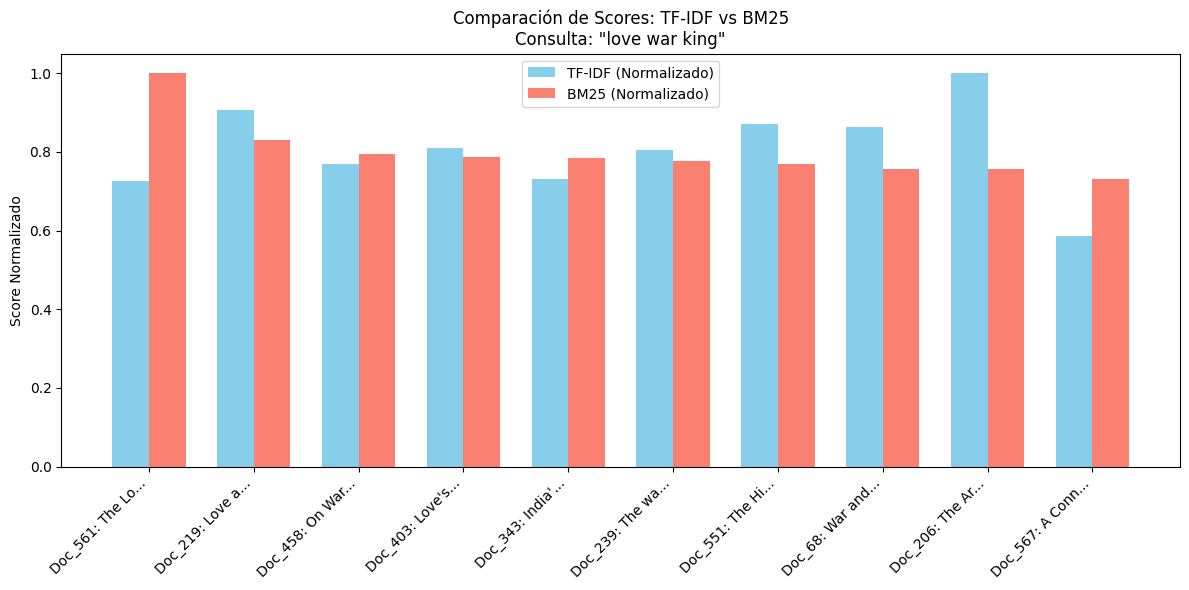

In [5]:
# 1. Gráfico de barras para visualizar los scores
# Tomamos el Top 10 de BM25 para comparar
top_10_docs = ranking_bm25.head(10)['Documento'].tolist()

scores_bm25_plot = [ranking_bm25[ranking_bm25['Documento'] == d]['Score BM25'].values[0] for d in top_10_docs]
scores_tfidf_plot = [ranking_tfidf[ranking_tfidf['Documento'] == d]['Score TF-IDF'].values[0] for d in top_10_docs]

# Normalizamos los scores al rango 0-1 para compararlos
scores_bm25_norm = np.array(scores_bm25_plot) / max(scores_bm25_plot) if max(scores_bm25_plot) > 0 else scores_bm25_plot
scores_tfidf_norm = np.array(scores_tfidf_plot) / max(scores_tfidf_plot) if max(scores_tfidf_plot) > 0 else scores_tfidf_plot

x = np.arange(len(top_10_docs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, scores_tfidf_norm, width, label='TF-IDF (Normalizado)', color='skyblue')
rects2 = ax.bar(x + width/2, scores_bm25_norm, width, label='BM25 (Normalizado)', color='salmon')

ax.set_ylabel('Score Normalizado')
ax.set_title(f'Comparación de Scores: TF-IDF vs BM25\nConsulta: "{consulta}"')
ax.set_xticks(x)
ax.set_xticklabels([d[:15]+"..." for d in top_10_docs], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()